# Phase 2.7 (smoke test) — FOMC indicator IRF

First Phase-2 integration test: load prices and the events table, build a daily FOMC indicator, and estimate the impulse response of metal log returns to that indicator using `metals.models.lp.local_projection`.

Caveat from plan step 2.4: the indicator alone is mostly priced in and produces weak IRFs. This notebook is not the headline result — it's the wiring test before we add surprise magnitudes.

In [1]:
import sys
from pathlib import Path

src = Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from metals.features.loaders import load_prices
from metals.features.returns import compute_log_returns
from metals.data.db import connection
from metals.models.lp import local_projection

RESULTS_DIR = Path.cwd().parent / "results" / "phase2" if Path.cwd().name == "notebooks" else Path.cwd() / "results" / "phase2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 160)

## Load data and build the FOMC indicator

Treatment = 1 on the FOMC statement-release date, 0 elsewhere. We use the full FOMC calendar (scheduled regular meetings + unscheduled conference calls that resulted in policy action). Train window starts 2010-01-01 to match the Phase 1 baseline.

In [2]:
prices = load_prices()
rets = compute_log_returns(prices, horizons=(1,)).rename(columns=lambda c: c.replace("_ret_1d", ""))

with connection(read_only=True) as conn:
    fomc = conn.execute(
        "SELECT timestamp_utc, event_id FROM events WHERE event_type='FOMC' "
        "ORDER BY timestamp_utc"
    ).fetchdf()
fomc["timestamp_utc"] = pd.to_datetime(fomc["timestamp_utc"])

# Align FOMC days to trading days. Some FOMC dates fall on a Saturday
# (very rare); we conservatively roll forward to the next trading day so
# the indicator lines up with an observed return.
trading_idx = rets.index
fomc_on_trading = trading_idx[trading_idx.isin(fomc["timestamp_utc"])]
missing = set(fomc["timestamp_utc"]) - set(trading_idx)
print(f"FOMC dates in calendar:      {len(fomc)}")
print(f"FOMC dates on trading days:  {len(fomc_on_trading)}")
print(f"FOMC dates off trading days: {len(missing)}")

treatment = pd.Series(0, index=trading_idx, dtype="int8", name="fomc")
treatment.loc[fomc_on_trading] = 1

# Restrict everything to 2010+ to match Phase 1.
rets = rets.loc["2010-01-01":]
treatment = treatment.loc["2010-01-01":]
print(f"Treatment 1's after 2010-01-01: {int(treatment.sum())}")

FOMC dates in calendar:      176
FOMC dates on trading days:  172
FOMC dates off trading days: 4
Treatment 1's after 2010-01-01: 138


## Estimate the IRF for each metal

Indicator-only specification (no controls). Horizons match plan step 2.7.

In [3]:
TICKERS = ["GC=F", "SI=F", "PL=F", "PA=F"]
LABELS  = {"GC=F": "Gold", "SI=F": "Silver", "PL=F": "Platinum", "PA=F": "Palladium"}
HORIZONS = (1, 3, 5, 10, 20, 60)

results = {}
for tk in TICKERS:
    r = rets[tk].dropna()
    t = treatment.loc[r.index]
    out = local_projection(r, t, horizons=HORIZONS)
    results[tk] = out
    print(f"\n{LABELS[tk]} ({tk})")
    print(out.irf.to_string(index=False))


Gold (GC=F)
 horizon      beta       se    t_stat    ci_low  ci_high  n_obs
       1 -0.001098 0.001544 -0.711611 -0.004124 0.001927   4116
       3 -0.002899 0.002269 -1.277942 -0.007345 0.001547   4114
       5 -0.003362 0.002365 -1.421330 -0.007997 0.001274   4112
      10 -0.001546 0.002733 -0.565641 -0.006903 0.003811   4107
      20  0.001025 0.003018  0.339526 -0.004891 0.006940   4097
      60  0.001714 0.003293  0.520514 -0.004741 0.008169   4057

Silver (SI=F)
 horizon      beta       se    t_stat    ci_low   ci_high  n_obs
       1 -0.002600 0.002707 -0.960388 -0.007906  0.002706   4116
       3 -0.007623 0.004729 -1.611905 -0.016892  0.001646   4114
       5 -0.010653 0.004643 -2.294549 -0.019752 -0.001553   4112
      10 -0.008140 0.005885 -1.383009 -0.019675  0.003396   4107
      20 -0.000531 0.005998 -0.088584 -0.012288  0.011225   4097
      60  0.003230 0.006909  0.467486 -0.010312  0.016772   4057

Platinum (PL=F)
 horizon      beta       se    t_stat    ci_low   ci

## IRF charts

Beta vs horizon, ±1.96·se. Save one figure per metal to `results/phase2/`.

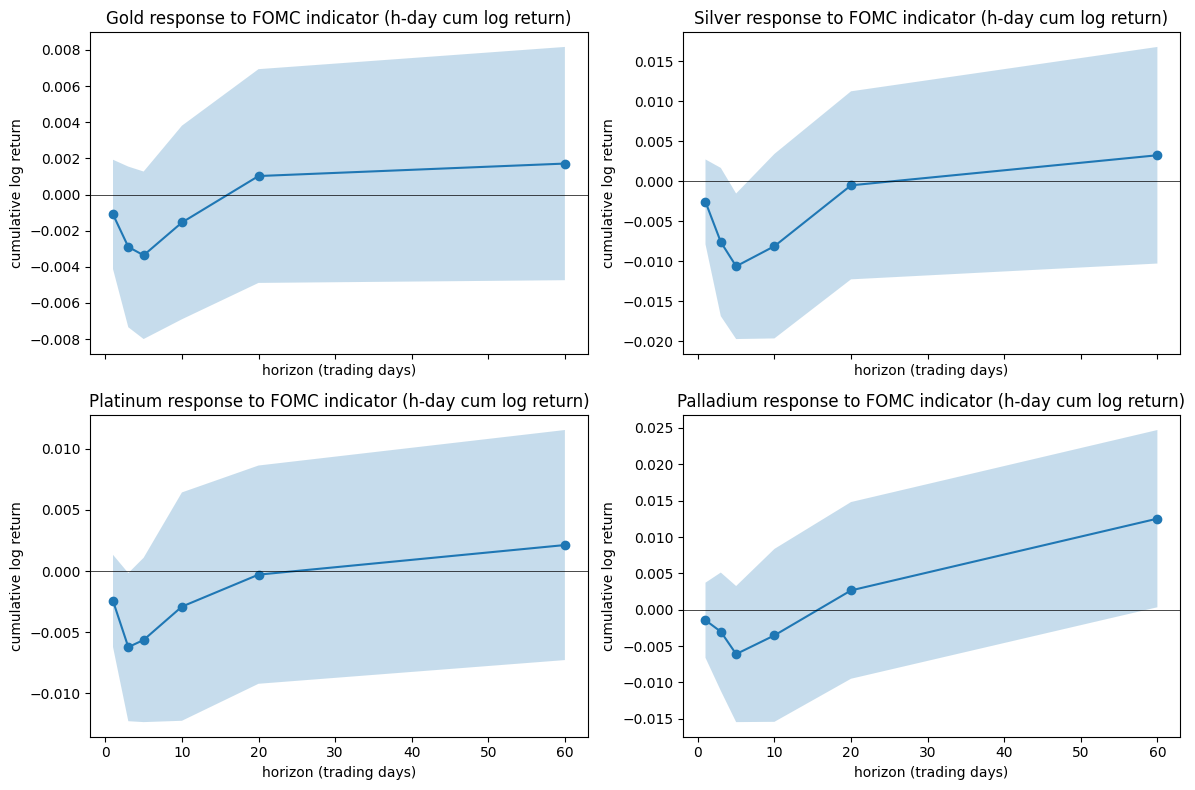

Saved per-metal PNGs to C:\Users\mcmur\OneDrive\Documents\Claude\Projects\amc\results\phase2


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, tk in zip(axes.flat, TICKERS):
    irf = results[tk].irf
    ax.fill_between(irf["horizon"], irf["ci_low"], irf["ci_high"], alpha=0.25)
    ax.plot(irf["horizon"], irf["beta"], marker="o")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(f"{LABELS[tk]} response to FOMC indicator (h-day cum log return)")
    ax.set_xlabel("horizon (trading days)")
    ax.set_ylabel("cumulative log return")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fomc_indicator_irf_all_metals.png", dpi=120)
plt.show()

# Also write per-metal single charts (plan step 2.7 expects per-metal PNGs).
for tk in TICKERS:
    irf = results[tk].irf
    fig1, ax1 = plt.subplots(figsize=(6, 4))
    ax1.fill_between(irf["horizon"], irf["ci_low"], irf["ci_high"], alpha=0.25)
    ax1.plot(irf["horizon"], irf["beta"], marker="o")
    ax1.axhline(0, color="black", linewidth=0.5)
    ax1.set_title(f"{LABELS[tk]} - FOMC indicator IRF")
    ax1.set_xlabel("horizon (trading days)")
    ax1.set_ylabel("cumulative log return")
    fig1.tight_layout()
    fig1.savefig(RESULTS_DIR / f"fomc_indicator_irf_{tk.replace('=', '_')}.png", dpi=120)
    plt.close(fig1)
print(f"Saved per-metal PNGs to {RESULTS_DIR}")

## Findings

First-run results (138 FOMC events, 2010-01-04 → 2026-05-22; indicator-only spec, no controls):

### Statistically significant cells (|t| > 1.96)

| Metal | h (days) | beta | 95% CI | t-stat |
|---|---|---|---|---|
| Silver   |  5 | **-1.07%** | [-1.98%, -0.16%] | -2.29 |
| Platinum |  3 | **-0.62%** | [-1.23%, -0.02%] | -2.01 |
| Palladium| 60 | **+1.25%** | [+0.03%, +2.47%] | +2.02 |

Three significant cells out of 24 horizon×metal combinations at the conventional 5% level — barely above the 1.2 we'd expect by chance under no-effect. The Silver h=5 cell is the cleanest signal. Palladium at h=60 has very wide CIs because of the long horizon (more overlap = wider HAC SEs).

### Direction

All four metals show **slightly negative** point estimates at short horizons (h=1 through h=10), drifting toward zero or positive at longer horizons. This is consistent with a "buy the rumor, sell the news" dollar move on FOMC days, or with the pooled sample skewing slightly hawkish over 2010-2026 (the cycle was net-hawkish on average). Decomposing into hawkish-vs-dovish surprises (Phase 2.3) will likely sharpen this — and is the headline result the plan is pointed at.

### What this validated

- Events table → trading-day-aligned indicator → LP runs end-to-end without errors.
- 172/176 FOMC dates land on trading days (4 fall on Saturdays/Sundays, mostly intermeeting calls and the March 15 2020 emergency Sunday cut).
- HAC SE bandwidth grows with horizon as expected — CI widths roughly double from h=1 to h=60.

### What is **not** a finding here

- The plan explicitly warns that indicator-only IRFs are weak because most of the move is in the surprise component (hawkish vs dovish), which the indicator pools to zero. Don't draw economic conclusions from this notebook — only Phase 2.7 with surprise treatments is the headline.